In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
modelos = [
    'ALMAClassifier',
    'AMFClassifier',
    'ARFClassifier',
    'ExtremelyFastDecisionTreeClassifier',
    'HoeffdingAdaptiveTreeClassifier',
    'HoeffdingTreeClassifier',
    'KNNClassifier'
]

sigla_modelos = {
    'ALMAClassifier': ('ALMA', '#1f77b4'),
    'AMFClassifier': ('AMF', '#ff7f0e'),
    'ARFClassifier': ('ARF', '#2ca02c'),
    'ExtremelyFastDecisionTreeClassifier': ('EFDT', '#d62728'),
    'HoeffdingAdaptiveTreeClassifier': ('HAT', '#9467bd'),
    'HoeffdingTreeClassifier': ('HT', '#8c564b'),
    'KNNClassifier': ('KNN', '#e377c2'),
}

In [8]:
df = pd.DataFrame(columns=['modelo', 'REC_inference_elapsed_time', 'cenario'])
for m in modelos:
    for i in range(4):
        df_REC = pd.read_csv(f'./../experiment/modelo_treinado/{m}_cenario_{i}/recomendacao_incremental_model.csv')['REC_inference_elapsed_time'].to_frame()
        df_REC['modelo'] = sigla_modelos.get(m)[0]
        df_REC['cenario'] = i + 1
        df = pd.concat([df, df_REC])

/tmp/ipykernel_47416/478522005.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_REC])
/tmp/ipykernel_47416/478522005.py:4: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_REC = pd.read_csv(f'./../experiment/modelo_treinado/{m}_cenario_{i}/recomendacao_incremental_model.csv')['REC_inference_elapsed_time'].to_frame()


/tmp/ipykernel_47416/2621627749.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_47416/2621627749.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_47416/2621627749.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_47416/2621627749.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


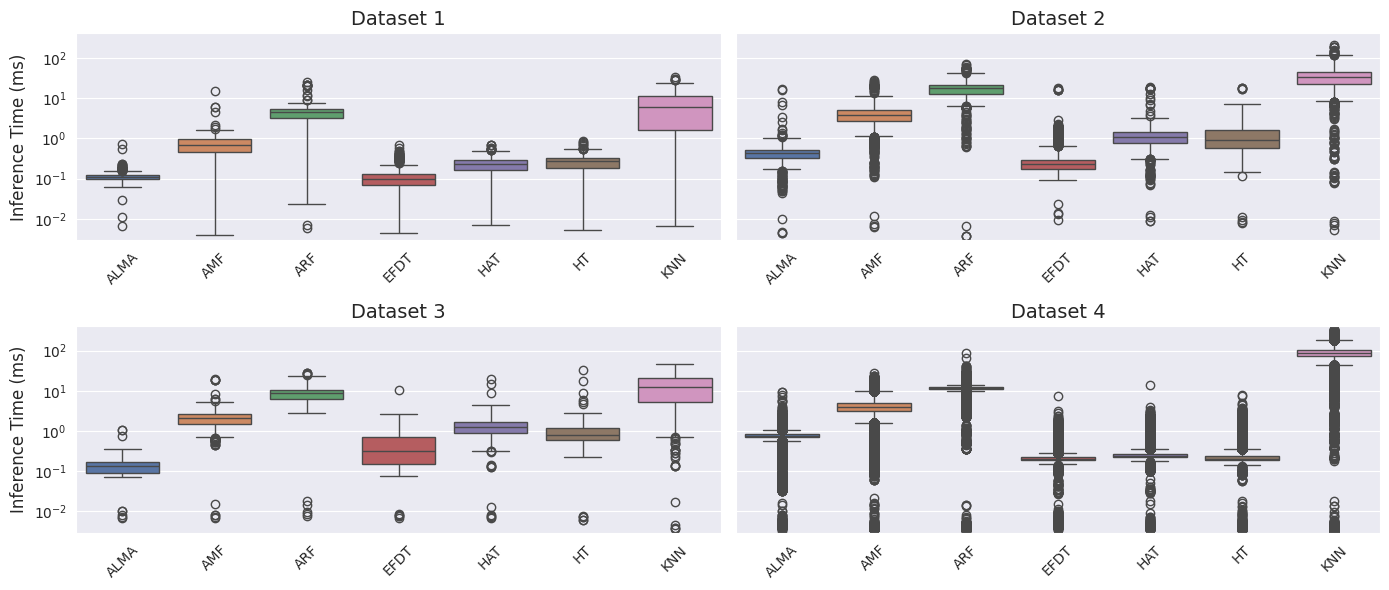

In [9]:

# 1. Identificar cenários únicos e ordená-los
cenarios = sorted(df['cenario'].unique())
num_cenarios = len(cenarios)

# 2. Configurar a figura e a matriz de subplots 2x2, utilizando 'sharey=True'
# O 'sharey=True' garante que todos os subplots usem a mesma escala logarítmica Y
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharey=True)
axes = axes.flatten()

# 3. Determinar o limite inferior mínimo para o eixo Y
# Isso é importante para a escala logarítmica (não pode ser zero)
min_val = df['REC_inference_elapsed_time'].min()
max_val = df['REC_inference_elapsed_time'].max()

# 4. Loop para iterar sobre cada cenário e plotar em um subplot
for i, cenario in enumerate(cenarios):
    # Filtrar o DataFrame para o cenário atual
    df_cenario = df[df['cenario'] == cenario]

    # Selecionar o eixo (subplot) atual
    ax = axes[i]

    # Gerar o Box Plot usando Seaborn
    sns.boxplot(
        x='modelo',
        y='REC_inference_elapsed_time',
        data=df_cenario,
        palette='deep',
        ax=ax,
    )

    # --- Ação Chave: Aplicar a Escala Logarítmica ---
    ax.set_yscale('log')

    # Definir o limite inferior do eixo Y ligeiramente abaixo do menor valor
    ax.set_ylim(bottom=min_val * 0.9, top=max_val * 0.9)

    # Configurações do gráfico
    ax.set_title(f'Dataset {cenario}', fontsize=14)
    ax.set_xlabel('', fontsize=12)

    # Colocar o rótulo do eixo Y apenas na primeira coluna para evitar redundância
    if i % 2 == 0:
        ax.set_ylabel('Inference Time (ms)', fontsize=12)
    else:
        ax.set_ylabel('')

    # Rotacionar os rótulos do eixo X
    ax.tick_params(axis='x', rotation=45)

# 5. Ocultar subplots não utilizados
# Se houver menos de 4 cenários, os eixos restantes são removidos
for j in range(num_cenarios, 4):
    fig.delaxes(axes[j])

# 6. Adicionar título geral e ajustar o layout
# fig.suptitle('Distribuição do Tempo de Inferência por Modelo - Comparação em Escala Logarítmica', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1])